In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Matplotlib is building the font cache; this may take a moment.


In [4]:
df=pd.read_csv("job_salary_prediction_dataset.csv")

In [6]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [15]:
df.shape

(250000, 10)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [17]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [18]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [19]:
df.duplicated().sum()

0

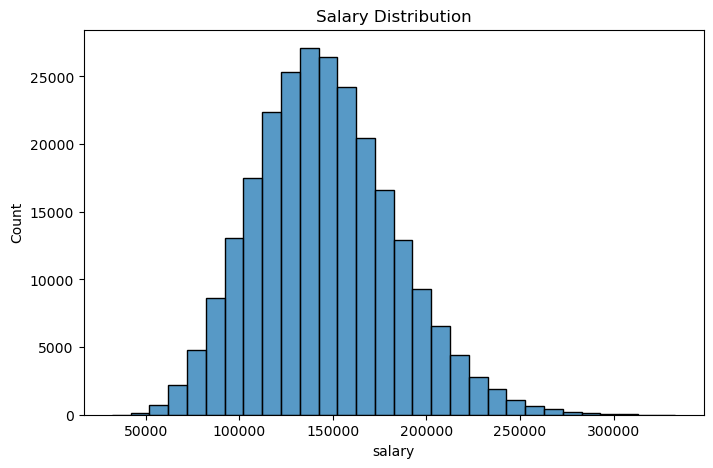

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary"], bins=30)

plt.title("Salary Distribution")
plt.show()

In [21]:
industry_salary = (
    df.groupby("industry")["salary"]
      .mean()
      .sort_values(ascending=False)
)

industry_salary

industry
Education        145993.564547
Media            145891.271071
Telecom          145876.511967
Technology       145863.808377
Finance          145801.639468
Healthcare       145759.995702
Government       145613.869242
Manufacturing    145530.603301
Consulting       145451.638293
Retail           145399.699408
Name: salary, dtype: float64

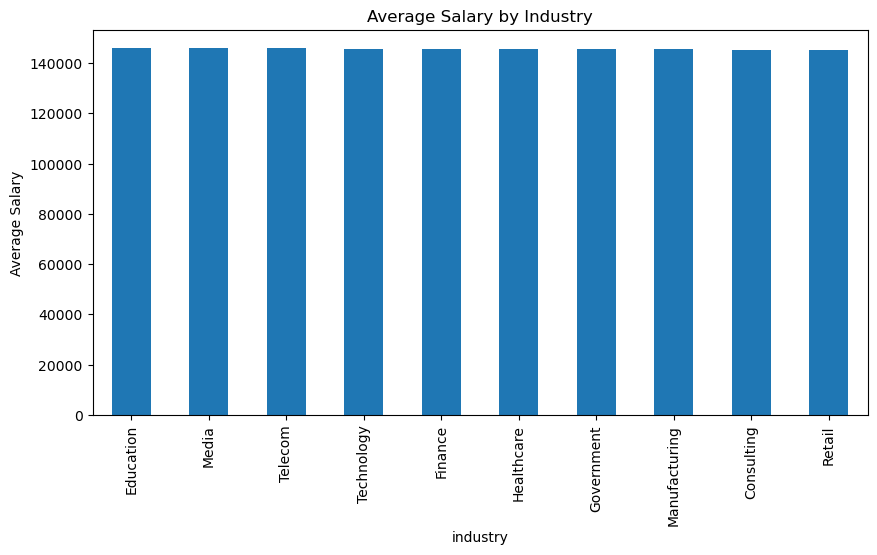

In [22]:
industry_salary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Salary by Industry")
plt.ylabel("Average Salary")
plt.show()

In [ ]:
# The Technology industry has the highest average salary, while the Retail industry has the lowest average salary.

In [25]:
#Does more education (BSc vs MSc vs PhD) actually lead to a higher salary?
education_salary = (
    df.groupby("education_level")["salary"]
      .mean()
      .sort_values()
)

education_salary

education_level
High School    131715.336243
Diploma        137158.574976
Bachelor       142410.531291
Master         153305.307833
PhD            163976.005295
Name: salary, dtype: float64

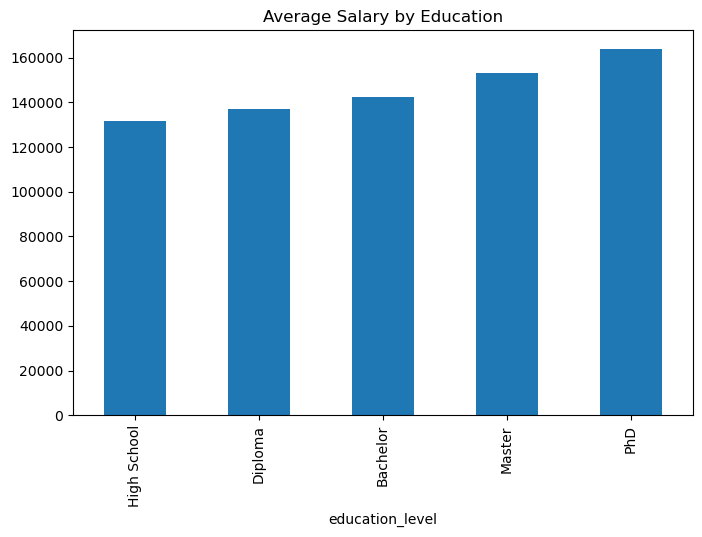

In [26]:
education_salary.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Salary by Education")
plt.show()

In [27]:
#Does location matter, do jobs in big cities pay more than remote or rural jobs?
location_salary = (
    df.groupby("location")["salary"]
      .mean()
      .sort_values()
)

location_salary

location
India           97690.402249
Netherlands    139294.813644
Singapore      139340.696625
Australia      139362.150804
Sweden         139440.637291
Remote         139442.525155
Germany        153376.211000
UK             160075.143018
Canada         167391.273396
USA            181716.303919
Name: salary, dtype: float64

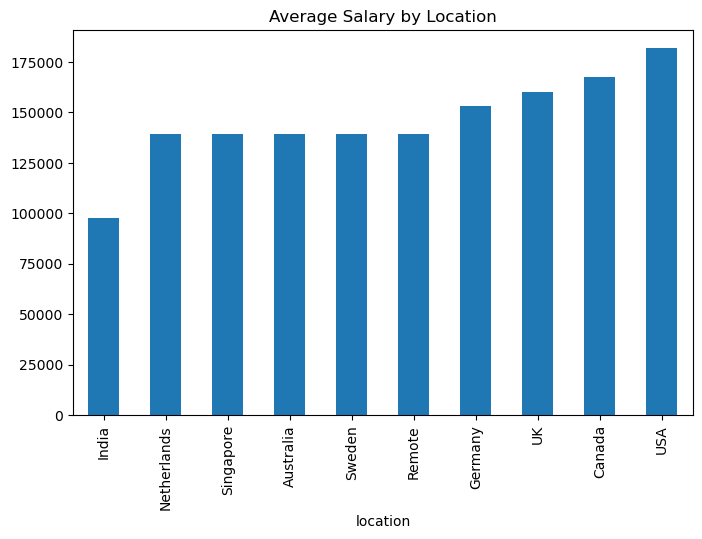

In [28]:
location_salary.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Salary by Location")
plt.show()

In [29]:
# Which factor matters most for salary prediction, job title, experience, or the skills you have?
X = df.drop("salary", axis=1)
y = df["salary"]

In [30]:
categorical_columns = X.select_dtypes(include="object").columns

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
# Build a machine learning model that predicts the salary
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

In [ ]:
model.fit(X_train, y_train)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)